# How the IBL spreadsheet is measured

1. **What is in IBL?** The Brainwide Map (BWM) release: which sessions, which files, what we kept.
2. **From that, how do we get the spreadsheet numbers?** Subjects, trials, neurons, length, sizes.
3. **Figures.** Neurons, firing rates, trials (by stimulus and block), trials × neurons, regions, raster.

The spike data lives on HAL (`~/ismael/ibl/data`, 321.6 GB). `data/ibl/ibl_extract.py` reduced it there to
the small tables in `data/ibl/tables/` (36 MB), which this notebook reads.

## 1. What is in IBL

- **Brainwide Map 2024 release** (`tag='Brainwidemap'` on the public server): **459 sessions, 12 labs, 139 mice,
  699 sorted insertions, 621,733 sorted units**. Insertions are Neuropixels 1.0 except 4 Neuropixels 2.0
  (steinmetzlab NR_0029, probe type NP2.4 in Alyx). Every session is the same task.
- **Task** — IBL visual decision task. A grating appears left or right at contrast 0, 6.25, 12.5, 25 or 100 %;
  the mouse turns a wheel to center it; water if correct. Each session starts with ~90 unbiased trials
  (P(left) = 0.5), then alternates biased blocks with P(left) = 0.2 or 0.8.
- **Spike sorting** — the 2024-05 pykilosort re-sort (`alf/probeXX/pykilosort/#2024-05-06#`). All units are
  released; IBL marks **good** units with `label == 1` (amplitude > 50 µV, noise cut-off, no refractory violations).
- **BrainWideBench (BWB)** uses 452 of these sessions (7 dropped by their evaluation-animal QC) in two builds:
  `all_units` (behavior decoding) and `selected_units` = `label == 1` & firing rate > 1 Hz (neural prediction,
  region ID). Its trial QC drops trials missing any of `stimOn`, `probabilityLeft`, `firstMovement`, `choice`,
  `feedback`, `feedbackType`, or with reaction time > 10 s.

**What a session folder holds, and what we kept** (server sizes, default revisions, `ibl_size_scan.py`):

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

here = Path.cwd().resolve()
REPO = here
for candidate in [here, *here.parents]:
    if (candidate / "src" / "ladys").is_dir() or (candidate / "data" / "ibl" / "tables").exists():
        REPO = candidate
        break
TABLES = REPO / "data" / "ibl" / "tables"
FIGURE_DIR = REPO / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
assert TABLES.exists(), f"Expected extracted tables at {TABLES}; see data/ibl/README.md"
GB = 1e9

sessions = pd.read_parquet(TABLES / "sessions.parquet")
probes = pd.read_parquet(TABLES / "probes.parquet")
units = pd.read_parquet(TABLES / "units.parquet")
trials = pd.read_parquet(TABLES / "trials.parquet")
server = pd.read_csv(TABLES / "server_sizes.csv")

units["good"] = units.label == 1
units["selected"] = units.good & (units.firing_rate > 1)
sessions = sessions.sort_values("trials", ignore_index=True)

folders = {
    "alf/": ("processed, time-synced data", "subset kept (below)"),
    "raw_ephys_data/": ("30 kHz AP + 2.5 kHz LFP voltage", "ditched"),
    "raw_video_data/": ("camera videos", "ditched"),
    "raw_passive_data/": ("passive stimulus logs", "ditched"),
    "raw_behavior_data/": ("task logs", "ditched"),
    "spike_sorters/": ("sorter outputs", "ditched"),
    "logs/": ("pipeline logs", "ditched"),
}
display(pd.DataFrame([
    {"folder": k, "what": w, "server GB": round(server[k.rstrip("/") + "_GB"].sum(), 1), "kept?": kept}
    for k, (w, kept) in folders.items()
]))
print(f"whole release, default revisions: {server.default_GB.sum():,.1f} GB "
      f"({server.all_revisions_GB.sum():,.1f} GB incl. old revisions)")

,folder,what,server GB,kept?
0,alf/,"processed, time-synced data",4550.3,subset kept (below)
1,raw_ephys_data/,30 kHz AP + 2.5 kHz LFP voltage,31789.4,ditched
2,raw_video_data/,camera videos,5766.0,ditched
3,raw_passive_data/,passive stimulus logs,1.6,ditched
4,raw_behavior_data/,task logs,0.0,ditched
5,spike_sorters/,sorter outputs,0.0,ditched
6,logs/,pipeline logs,0.0,ditched


whole release, default revisions: 42,107.3 GB (43,036.0 GB incl. old revisions)


**Kept from `alf/`** (`ibl_download.py`, default revision only):

| Files | What | Used for |
|---|---|---|
| `probeXX/pykilosort/spikes.{times,clusters}.npy` | every spike of every unit | NEURONS, LENGTH, stats (all-units build) |
| `probeXX/pykilosort/clusters.{metrics.pqt,channels,depths,uuids}` | unit QC label, firing rate, depth | QC counts |
| `probeXX/pykilosort/channels.{brainLocationIds_ccf_2017,mlapdv,localCoordinates,rawInd}` | channel positions + atlas region | regions |
| `_ibl_trials.table.pqt` | one row per trial: contrast, block, choice, event times | TRIALS |
| `_ibl_wheel.*`, `licks.times`, `_ibl_leftCamera.{times,lightningPose}`, `leftCamera.ROIMotionEnergy` | behavior streams BWB decodes | BENCHMARK size |

Three quirks found while extracting (all handled):

- **23 probes** had their channel locations only in a revision *not* flagged default; the downloader falls back to the newest one.
- **74 files (0.078 GB)** are older revisions the server also flags default (68 probes). The newest revision is read; the older copies are excluded from BENCHMARK size.
- **CSHL045 2020-02-25/002 probe00** has insertion QC `CRITICAL` and was never sorted: 700 probe folders, 699 sorted probes.

In [2]:
checks = {
    "sessions": (len(sessions), 459),
    "labs": (sessions.lab.nunique(), 12),
    "subjects (mice)": (sessions.subject.nunique(), 139),
    "sorted probes": (len(probes), 699),
    "units": (len(units), 621_733),
}
display(pd.DataFrame(checks, index=["measured", "BWM paper"]).T)
for name, (measured, paper) in checks.items():
    assert measured == paper, name
assert sessions.unsorted_probes.sum() == 1
assert probes.groupby("eid").units.sum().sum() == sessions.units.sum() == len(units)

print("units by IBL label:")
display(units.label.round(3).value_counts().sort_index().rename("units").to_frame().T)

,measured,BWM paper
sessions,459,459
labs,12,12
subjects (mice),139,139
sorted probes,699,699
units,621733,621733


units by IBL label:


label,0.000,0.333,0.667,1.000
units,112878,255535,177612,75708


## 2. How those files become spreadsheet numbers

- **SUBJECTS** — mice (`subject` in the session path): 139.
The row uses **BrainWideBench (BWB) definitions**, applied to all 459 sessions. BWB also drops 7 sessions
("failed QC on the evaluation animals"), but its paper does not list them, so they cannot be removed here.

- **TRIALS** — trials passing BWB trial QC (all six task events present, reaction time ≤ 10 s).
  All trials (every row of `_ibl_trials.table`) go in NOTES.
- **NEURONS** — BWB `selected_units`: IBL good (`label == 1`) & firing rate > 1 Hz. TOTAL = sum;
  MEDIAN = per session (units on all probes of a session are simultaneous). BWB applies probe QC to its
  evaluation sessions only, which is not reproduced. All units (`all_units`) and good units go in NOTES.
- **CHANNELS** — `N/A` (sorted units). Hardware (Neuropixels 1.0 except 4 NP2.0 insertions, 1–2 probes per session) goes in NOTES.
- **LENGTH** — per session, first to last spike across its probes (this includes time between and after trials; BWB's
  TS2 task splits the recording into 5-minute time blocks, its other tasks split by trial), summed over sessions. Time inside the task (first trial start to last trial end) is in NOTES.
- **RAW** — the whole public release for these sessions (default revisions), incl. raw voltage and video.
- **BENCHMARK** — a selected-units build: spike times/clusters of selected units only (12 bytes per spike, as
  in the download) plus every non-spike file of the keep-set above (minus the 74 stale duplicate files).
- **BASIC STATS** — one firing rate per selected unit: IBL's `clusters.metrics.firing_rate` (spike count / recording time).

Per-session table (sorted by trials):

In [3]:
sessions["recording_min"] = sessions.recording_s / 60
sessions["task_min"] = sessions.task_s / 60
cols = ["lab", "subject", "date", "probes", "units", "good_units", "selected_units",
        "trials", "bwb_trials", "recording_min", "task_min"]
display(sessions[cols].describe().round(1))
display(sessions[["eid"] + cols].head(3))

,probes,units,good_units,selected_units,trials,bwb_trials,recording_min,task_min
count,459.0,459.0,459.0,459.0,459.0,459.0,459.0,459.0
mean,1.5,1354.5,164.9,151.2,645.1,626.5,80.0,57.2
std,0.5,642.8,103.2,96.0,197.6,201.6,16.4,14.5
min,1.0,135.0,2.0,2.0,401.0,347.0,29.6,28.1
25%,1.0,860.0,91.0,82.0,497.0,471.0,68.3,45.9
50%,2.0,1299.0,142.0,132.0,601.0,586.0,78.2,55.0
75%,2.0,1803.5,218.5,203.0,763.0,755.0,89.7,66.0
max,2.0,3140.0,536.0,489.0,1525.0,1520.0,155.5,111.3


,eid,lab,subject,date,probes,units,good_units,selected_units,trials,bwb_trials,recording_min,task_min
0,3f6e25ae-c007-4dc3-aa77-450fd5705046,mainenlab,ZFM-01936,2021-01-24,1,841,136,120,401,398,54.267198,30.588989
1,8b1f4024-3d96-4ee7-95f9-8a1dfd4ce4ef,hausserlab,PL017,2021-11-09,1,1295,39,37,401,354,79.453101,46.507030
2,4a45c8ba-db6f-4f11-9403-56e06a33dfa4,danlab,DY_020,2020-09-29,2,1807,435,416,401,347,79.988911,56.420180


## 3. Figures

### Neurons per session

One histogram per unit set, each counting sessions by how many units of that set they have (sum over probes):
**all** sorted units, **IBL good** (`label == 1`), and **BWB selected** (good & > 1 Hz). Every session has
selected ≤ good ≤ all, so each histogram sits left of the previous one. The panels are kept separate because
overlaid, a subset's histogram can be taller in a low bin (more sessions land there), which reads as if the subset
were larger.

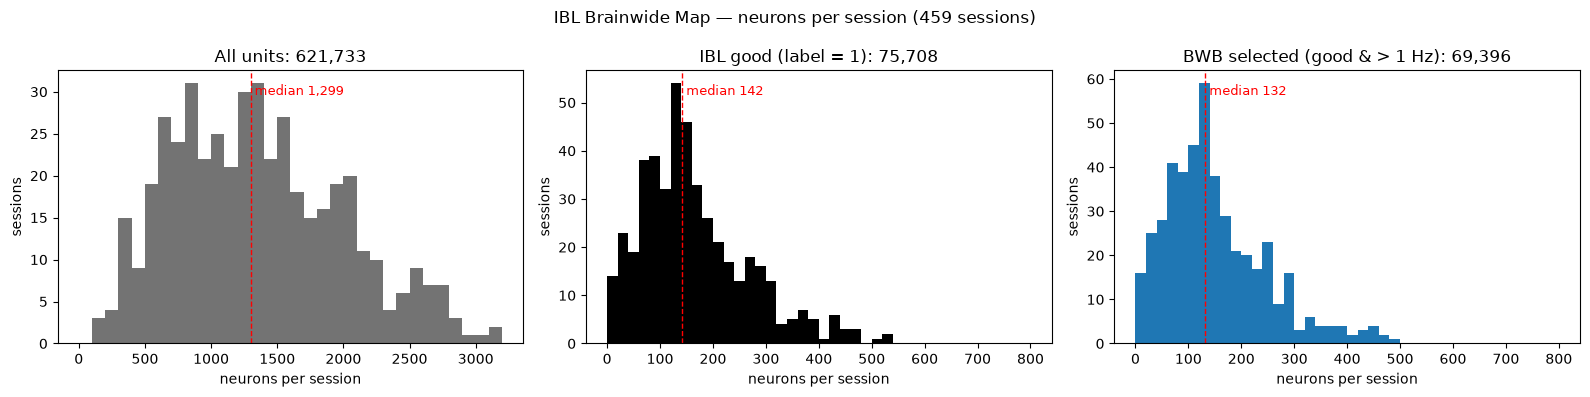

In [4]:
def median_line(ax, values, color="k"):
    m = float(np.median(values))
    ax.axvline(m, color=color, ls="--", lw=1)
    ax.text(m, ax.get_ylim()[1] * 0.95, f" median {m:,.0f}", color=color, va="top", fontsize=9)


assert (sessions.selected_units <= sessions.good_units).all() and (sessions.good_units <= sessions.units).all()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color, name, bins in [
    (axes[0], "units", "0.45", "All units", np.arange(0, 3300, 100)),
    (axes[1], "good_units", "k", "IBL good (label = 1)", np.arange(0, 820, 20)),
    (axes[2], "selected_units", "C0", "BWB selected (good & > 1 Hz)", np.arange(0, 820, 20)),
]:
    ax.hist(sessions[col], bins=bins, color=color)
    ax.set(title=f"{name}: {sessions[col].sum():,}", xlabel="neurons per session", ylabel="sessions")
    median_line(ax, sessions[col], "r")
fig.suptitle(f"IBL Brainwide Map — neurons per session ({len(sessions)} sessions)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_neurons_per_session.png", dpi=150)
plt.show()

### Firing rates

One rate per unit (`clusters.metrics.firing_rate`). Outline = IBL good, blue = BWB selected (good and > 1 Hz).
Selected is a subset of good, so blue always sits inside the outline; they differ only left of the dashed 1 Hz
line. All sorted units are left out of the plot (mostly noise and multi-unit clusters); their rates are in the
table below.

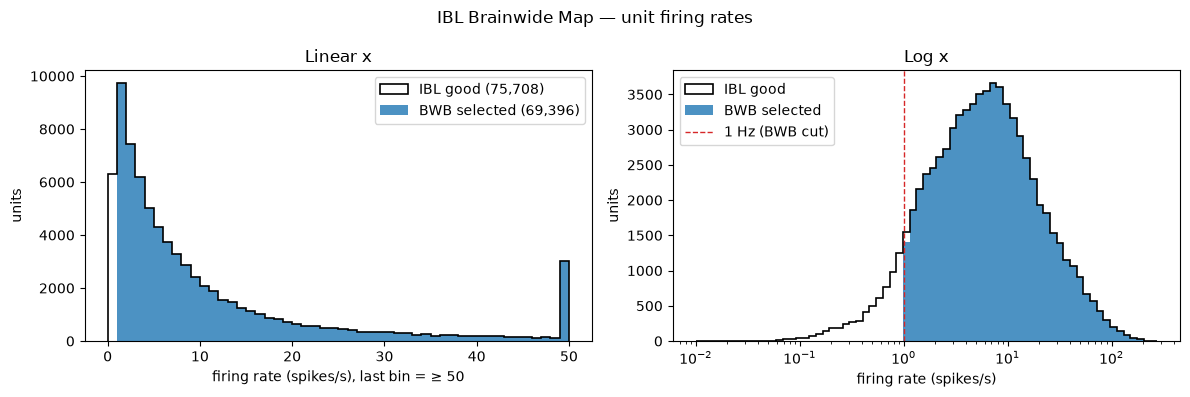

,units,mean Hz,median Hz
all,621733.0,7.04,4.42
good,75708.0,11.49,5.72
selected,69396.0,12.48,6.53


In [5]:
fr = units.firing_rate
good, sel = fr[units.good], fr[units.selected]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
bins = np.arange(0, 51, 1)
ax.hist(good.clip(upper=50), bins=bins, histtype="step", color="k", lw=1.2, label=f"IBL good ({len(good):,})")
ax.hist(sel.clip(upper=50), bins=bins, color="C0", alpha=0.8, label=f"BWB selected ({len(sel):,})")
ax.set(xlabel="firing rate (spikes/s), last bin = ≥ 50", ylabel="units", title="Linear x")
ax.legend()
ax = axes[1]
pos = good[good > 0]
bins = np.logspace(np.floor(np.log10(pos.min())), np.log10(pos.max()) + 0.05, 70)
ax.hist(pos, bins=bins, histtype="step", color="k", lw=1.2, label="IBL good")
ax.hist(sel, bins=bins, color="C0", alpha=0.8, label="BWB selected")
ax.axvline(1, color="C3", ls="--", lw=1, label="1 Hz (BWB cut)")
ax.set_xscale("log")
ax.set(xlabel="firing rate (spikes/s)", ylabel="units", title="Log x")
ax.legend()
fig.suptitle("IBL Brainwide Map — unit firing rates")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_firing_rates.png", dpi=150)
plt.show()

display(pd.DataFrame({
    name: {"units": int(mask.sum()), "mean Hz": fr[mask].mean(), "median Hz": fr[mask].median()}
    for name, mask in [("all", units.firing_rate.notna()), ("good", units.good), ("selected", units.selected)]
}).T.round(2))

### Trials per session

Sessions by trial count: all trials (filled) and trials passing BWB trial QC (outline).

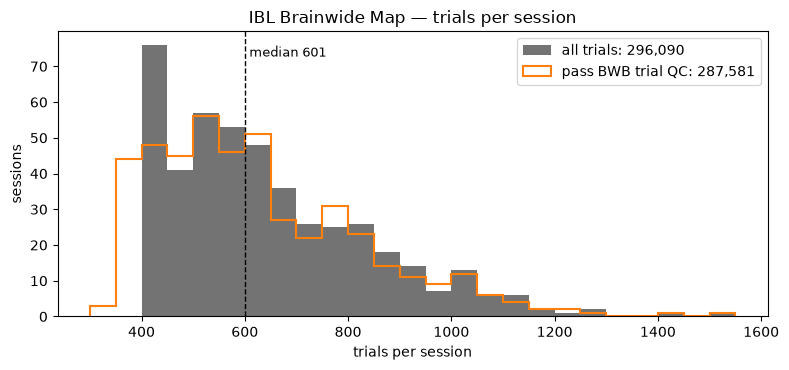

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.arange(300, 1575, 50)
ax.hist(sessions.trials, bins=bins, color="0.45", label=f"all trials: {sessions.trials.sum():,}")
ax.hist(sessions.bwb_trials, bins=bins, histtype="step", color="C1", lw=1.5,
        label=f"pass BWB trial QC: {sessions.bwb_trials.sum():,}")
ax.set(xlabel="trials per session", ylabel="sessions", title="IBL Brainwide Map — trials per session")
ax.legend()
median_line(ax, sessions.trials)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_trials_per_session.png", dpi=150)
plt.show()

### Trials by stimulus and context

Every session runs the same task generator: each trial's contrast and side are drawn at random, and the block
prior follows the same schedule (~90 unbiased trials, then alternating 0.2 / 0.8 blocks of random length).
So a session's mix is set by that generator, not by anything session-specific, and a table is enough; a
per-session plot would only show sampling noise. The noise is small for contrast (each ~11 %) but large for
the block prior: block lengths are random and sessions end at different trial counts, so P(left) = 0.8 is
anywhere from ~28 % to ~59 % of a session's trials.

- **Stimulus** — signed contrast: L = grating on the left, R = right; 0 % has no side.
- **Context** — block P(left): 0.5 = unbiased start, 0.2 = right-biased, 0.8 = left-biased.
- **% per session** — median [min – max] over the 459 sessions of that category's share of the session's trials.

In [7]:
trials["signed_contrast"] = trials.contrastRight.fillna(0) - trials.contrastLeft.fillna(0)
by_contrast = pd.crosstab(trials.eid, trials.signed_contrast)
by_block = pd.crosstab(trials.eid, trials.probabilityLeft)[[0.5, 0.2, 0.8]]
assert (by_contrast.sum(axis=1) == by_block.sum(axis=1)).all()
assert by_contrast.to_numpy().sum() == sessions.trials.sum()


def contrast_label(c):
    return "0 %" if c == 0 else f"{'L' if c < 0 else 'R'} {abs(c) * 100:g} %"


def mix_table(table, labels):
    share = table.div(table.sum(axis=1), axis=0) * 100
    return pd.DataFrame({
        "trials": table.sum().to_numpy(),
        "% of trials": (table.sum() / table.to_numpy().sum() * 100).round(1).to_numpy(),
        "% per session": [f"{share[c].median():.1f} [{share[c].min():.1f} – {share[c].max():.1f}]"
                          for c in table.columns],
    }, index=labels)


display(mix_table(by_contrast, [contrast_label(c) for c in by_contrast.columns]).rename_axis("stimulus"))
display(mix_table(by_block, [f"P(left) = {p:g}" for p in by_block.columns]).rename_axis("context"))

,trials,% of trials,% per session
stimulus,,,
L 100 %,33741,11.4,11.2 [7.8 – 14.5]
L 25 %,34584,11.7,11.8 [7.8 – 15.0]
L 12.5 %,33389,11.3,11.4 [7.7 – 13.5]
L 6.25 %,32733,11.1,11.0 [8.5 – 13.6]
0 %,34713,11.7,11.8 [8.2 – 13.7]
R 6.25 %,32266,10.9,11.1 [7.5 – 15.6]
R 12.5 %,31515,10.6,10.2 [8.7 – 14.2]
R 25 %,30699,10.4,10.0 [8.5 – 15.0]
R 100 %,32450,11.0,11.0 [8.1 – 14.6]


,trials,% of trials,% per session
context,,,
P(left) = 0.5,41310,14.0,15.0 [5.9 – 22.4]
P(left) = 0.2,123580,41.7,42.4 [28.1 – 55.8]
P(left) = 0.8,131200,44.3,43.0 [27.5 – 59.0]


### Trials × neurons

Each cell counts sessions with that many trials (x) and neurons (y). Top: number of sessions. Bottom: the same
as % of the 459 sessions. Columns: all units, IBL good (`label == 1`), BWB selected (good & > 1 Hz).

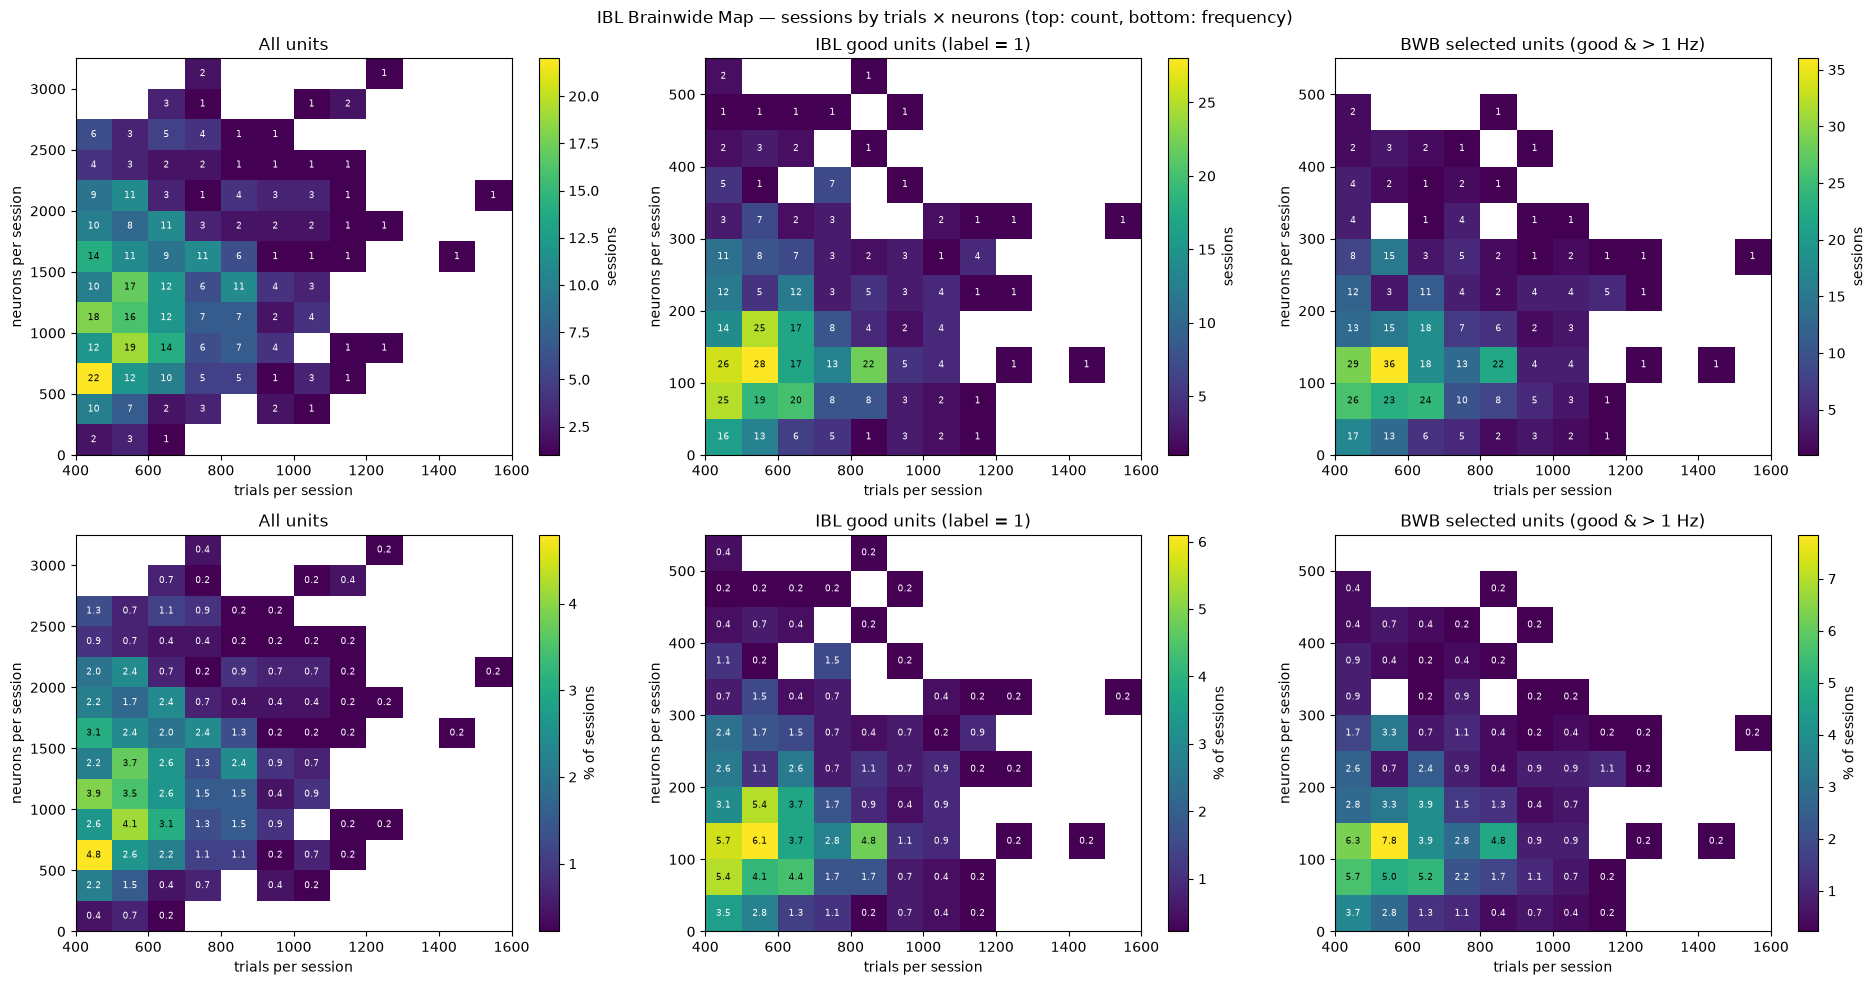

In [8]:
def heatmap(ax, x, y, xbins, ybins, percent, title):
    H, xe, ye = np.histogram2d(x, y, [xbins, ybins])
    if percent:
        H = H / len(x) * 100
    masked = np.ma.masked_equal(H.T, 0)
    im = ax.pcolormesh(xe, ye, masked, cmap="viridis", shading="flat")
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            if H[i, j]:
                txt = f"{H[i, j]:.1f}" if percent else f"{H[i, j]:.0f}"
                ax.text((xe[i] + xe[i + 1]) / 2, (ye[j] + ye[j + 1]) / 2, txt, ha="center", va="center",
                        fontsize=6.5, color="w" if H[i, j] < 0.6 * H.max() else "k")
    ax.set(title=title, xlabel="trials per session", ylabel="neurons per session")
    plt.colorbar(im, ax=ax, label="% of sessions" if percent else "sessions")


tbins = np.arange(400, 1601, 100)
qc_bins = np.arange(0, sessions.good_units.max() + 51, 50)
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for row, percent in enumerate([False, True]):
    heatmap(axes[row, 0], sessions.trials, sessions.units, tbins, np.arange(0, 3301, 250), percent,
            "All units")
    heatmap(axes[row, 1], sessions.trials, sessions.good_units, tbins, qc_bins, percent,
            "IBL good units (label = 1)")
    heatmap(axes[row, 2], sessions.trials, sessions.selected_units, tbins, qc_bins, percent,
            "BWB selected units (good & > 1 Hz)")
fig.suptitle("IBL Brainwide Map — sessions by trials × neurons (top: count, bottom: frequency)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_trials_x_neurons.png", dpi=150)
plt.show()

### Brain regions

Units per coarse atlas division (Cosmos mapping of each unit's channel). `root`/`void` = on a channel outside
an annotated region (e.g. above the brain surface or in fiber tracts).

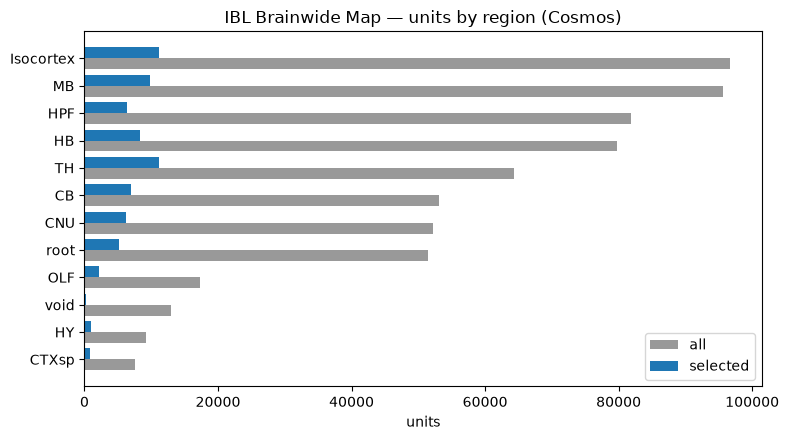

279 Beryl regions (excl. root/void), 580 Allen regions


In [9]:
reg = pd.DataFrame({"all": units.cosmos.value_counts(), "selected": units[units.selected].cosmos.value_counts()})
reg = reg.fillna(0).astype(int).sort_values("all")
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(reg))
ax.barh(y - 0.2, reg["all"], height=0.4, color="0.6", label="all")
ax.barh(y + 0.2, reg["selected"], height=0.4, color="C0", label="selected")
ax.set(yticks=y, yticklabels=reg.index, xlabel="units", title="IBL Brainwide Map — units by region (Cosmos)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_regions.png", dpi=150)
plt.show()
print(f"{units.beryl[~units.beryl.isin(['root', 'void'])].nunique()} Beryl regions (excl. root/void), {units.region.nunique()} Allen regions")

### Raster

The session with the median number of units (all units: 1,299); 30 s from its first stimulus onset. Rows = units, grouped by probe and
sorted by depth (tip at the bottom). Black = BWB selected, gray = the rest.

- **Green line** — stimulus onset (`stimOn_times`): the grating appears on the screen.
- **Red dashed line** — feedback (`feedback_times`): the mouse finished its wheel turn; water reward if the choice
  was correct, white-noise tone + timeout if wrong. The gap from green to red is the reaction + movement time.
- **Blue horizontal line** — boundary between the two probes' units (probe00 below, probe01 above).

The lighter bands ~0.5–1 s before each stimulus are real: the task requires the wheel to be held still
(quiescence period) before the stimulus appears, and movement-related firing drops: in the 0.5 s before stimulus onset the population rate is about 3/4 of
the task mean and about half of the rate 0.2–0.7 s after the stimulus.

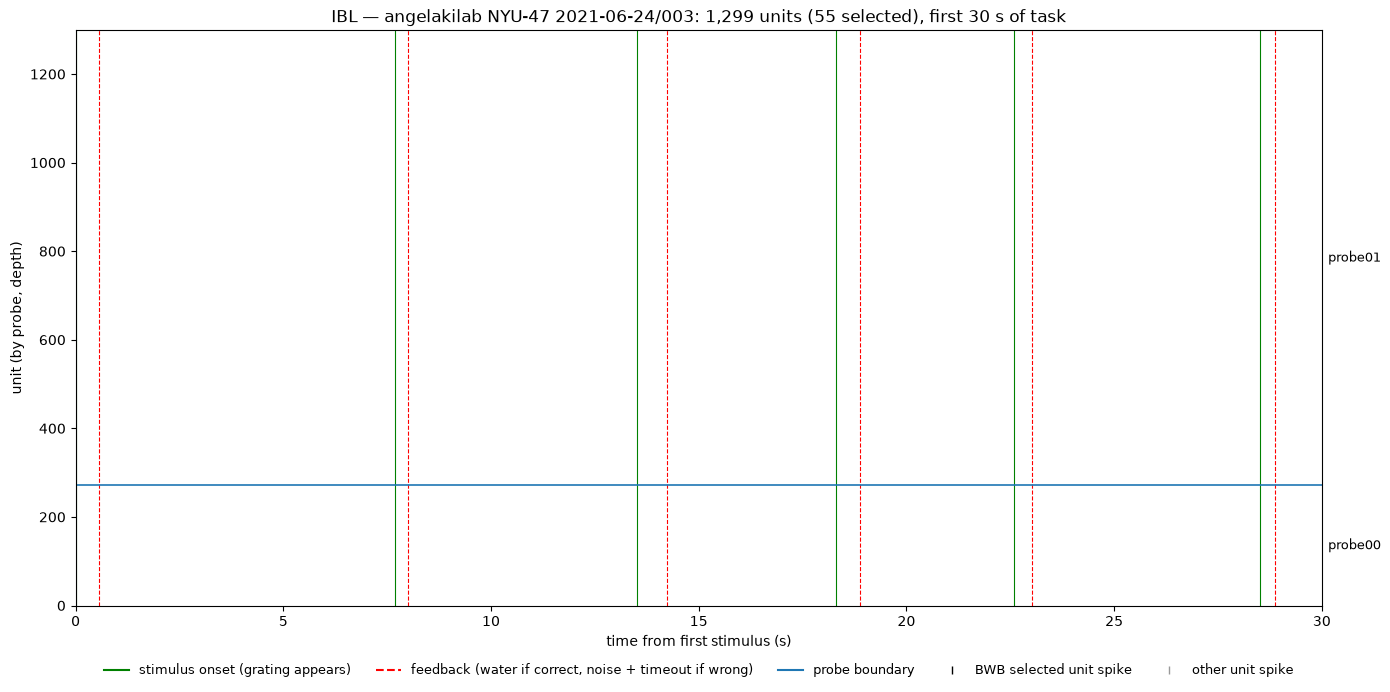

In [10]:
r = np.load(TABLES / "raster.npz")
eid = str(r["eid"])
s = sessions.set_index("eid").loc[eid]
u = units[units.eid == eid].sort_values(["probe", "depth_um"]).reset_index(drop=True)
u["row"] = np.arange(len(u))
spk = pd.DataFrame({"probe": r["probe"], "cluster_id": r["clusters"], "t": r["times"]}).merge(
    u[["probe", "cluster_id", "row", "selected"]], on=["probe", "cluster_id"], how="left", validate="many_to_one")
assert spk.row.notna().all()

fig, ax = plt.subplots(figsize=(14, 7))
for sel, color in [(False, "0.75"), (True, "k")]:
    d = spk[spk.selected == sel]
    ax.scatter(d.t, d.row, s=0.3, color=color, marker="|", linewidths=0.4, rasterized=True)
for t in r["stim_on"]:
    ax.axvline(t, color="g", lw=0.8)
for t in r["feedback"]:
    ax.axvline(t, color="r", lw=0.8, ls="--")
for p, grp in u.groupby("probe"):
    if grp.row.max() < len(u) - 1:
        ax.axhline(grp.row.max() + 0.5, color="C0", lw=1.2)
    ax.text(float(r["window_s"]) * 1.005, grp.row.mean(), p, va="center", fontsize=9)
ax.legend(handles=[
    plt.Line2D([], [], color="g", lw=1.5, label="stimulus onset (grating appears)"),
    plt.Line2D([], [], color="r", lw=1.5, ls="--", label="feedback (water if correct, noise + timeout if wrong)"),
    plt.Line2D([], [], color="C0", lw=1.5, label="probe boundary"),
    plt.Line2D([], [], color="k", marker="|", ls="", label="BWB selected unit spike"),
    plt.Line2D([], [], color="0.6", marker="|", ls="", label="other unit spike"),
], loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=9, frameon=False)
ax.set(xlim=(0, float(r["window_s"])), ylim=(-0.5, len(u) - 0.5), xlabel="time from first stimulus (s)",
       ylabel="unit (by probe, depth)",
       title=f"IBL — {s.lab} {s.subject} {s.date}/{s.number}: {len(u):,} units ({u.selected.sum()} selected), "
             f"first {float(r['window_s']):g} s of task")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ibl_raster.png", dpi=150)
plt.show()

## Spreadsheet

- Same columns as the NLB / FALCON CSVs. CHANNELS = `N/A` (sorted units).
- Length: 1 decimal minute. RAW / BENCHMARK: 3 decimal GB.
- This cell writes `tutorials/ibl_datasets.csv`.

In [11]:
stale_bytes = sessions.stale_bytes.sum()
downloaded_bytes = sessions.bytes.sum() - stale_bytes
non_spike_bytes = downloaded_bytes - sessions.spike_bytes.sum()
bytes_per_spike = sessions.spike_bytes.sum() / sessions.spikes.sum()
selected_spike_bytes = units.spike_count[units.selected].sum() * bytes_per_spike
benchmark_bytes = selected_spike_bytes + non_spike_bytes
fr_all, fr_sel = units.firing_rate, units.firing_rate[units.selected]

notes = (
    f"IBL Brainwide Map 2024 release, counted with BrainWideBench (BWB) definitions: {len(sessions)} sessions from "
    f"{sessions.lab.nunique()} labs (BWB uses 452; its 7 dropped sessions are not listed, so all 459 are counted); "
    f"one task (visual 2AFC contrast discrimination, wheel response, P(left) = 0.2/0.5/0.8 blocks); "
    f"{len(probes)} sorted insertions (Neuropixels 1.0 except 4 NP2.0, steinmetzlab NR_0029; 1–2 per session; 1 more insertion, CSHL045 probe00, "
    f"QC CRITICAL and unsorted); CHANNELS N/A because units are sorted (pykilosort 2024-05 re-sort). "
    f"NEURONS = BWB selected_units: IBL good (label = 1) & firing rate > 1 Hz (BWB's eval-session probe QC not "
    f"applied); all units {len(units):,} (median {sessions.units.median():.0f}/session, BWB all_units), IBL good "
    f"{units.good.sum():,} (median {sessions.good_units.median():.0f}/session). "
    f"TRIALS = pass BWB trial QC (six task events present, RT ≤ 10 s; median {sessions.bwb_trials.median():.0f}/session); "
    f"all trials {sessions.trials.sum():,}. "
    f"LENGTH = first-to-last spike per session, summed ({sessions.recording_s.sum() / 3600:,.1f} h); "
    f"in-task time {sessions.task_s.sum() / 60:,.1f} min. "
    f"RAW = whole public release for these sessions, default revisions (raw ephys "
    f"{server.raw_ephys_data_GB.sum() / 1000:.1f} TB, video {server.raw_video_data_GB.sum() / 1000:.1f} TB, "
    f"alf {server.alf_GB.sum() / 1000:.2f} TB). BENCHMARK = selected-unit spike times/clusters "
    f"({selected_spike_bytes / GB:.1f} GB) + unit/channel metadata, trials, wheel, licks, left-camera pose and "
    f"whisker motion energy where available (licks {sessions.has_licks.sum()}, pose {sessions.has_left_pose.sum()}, "
    f"motion energy {sessions.has_left_motion_energy.sum()} of {len(sessions)} sessions; "
    f"{non_spike_bytes / GB:.1f} GB); the all-units download is {downloaded_bytes / GB:.1f} GB."
)
row = {
    "DATASET": "IBL Brainwide Map",
    "ANIMAL": "Mouse",
    "SUBJECTS": sessions.subject.nunique(),
    "TRIALS": int(sessions.bwb_trials.sum()),
    "TOTAL CHANNELS": "N/A",
    "MEDIAN CHANNELS": "N/A",
    "TOTAL NEURONS": int(sessions.selected_units.sum()),
    "MEDIAN NEURONS": int(sessions.selected_units.median()),
    "RECORDING LENGTH (min)": round(sessions.recording_s.sum() / 60, 1),
    "RAW DATASET SIZE (GB)": round(server.default_GB.sum(), 3),
    "BENCHMARK DATASET SIZE (GB)": round(benchmark_bytes / GB, 3),
    "NOTES": notes,
    "BASIC STATS": (f"Selected-unit firing rate: mean {fr_sel.mean():.2f}, median {fr_sel.median():.2f} spikes/s "
                    f"(all units: mean {fr_all.mean():.2f}, median {fr_all.median():.2f})"),
}
inventory = pd.DataFrame([row])
display(inventory.drop(columns="NOTES").T)
print(notes)
csv_path = REPO / "tutorials" / "ibl_datasets.csv"
inventory.to_csv(csv_path, index=False)
print("wrote", csv_path)

,0
DATASET,IBL Brainwide Map
ANIMAL,Mouse
SUBJECTS,139
TRIALS,287581
TOTAL CHANNELS,N/A
MEDIAN CHANNELS,N/A
TOTAL NEURONS,69396
MEDIAN NEURONS,132
RECORDING LENGTH (min),36703.7
RAW DATASET SIZE (GB),42107.286


IBL Brainwide Map 2024 release, counted with BrainWideBench (BWB) definitions: 459 sessions from 12 labs (BWB uses 452; its 7 dropped sessions are not listed, so all 459 are counted); one task (visual 2AFC contrast discrimination, wheel response, P(left) = 0.2/0.5/0.8 blocks); 699 sorted insertions (Neuropixels 1.0 except 4 NP2.0, steinmetzlab NR_0029; 1–2 per session; 1 more insertion, CSHL045 probe00, QC CRITICAL and unsorted); CHANNELS N/A because units are sorted (pykilosort 2024-05 re-sort). NEURONS = BWB selected_units: IBL good (label = 1) & firing rate > 1 Hz (BWB's eval-session probe QC not applied); all units 621,733 (median 1299/session, BWB all_units), IBL good 75,708 (median 142/session). TRIALS = pass BWB trial QC (six task events present, RT ≤ 10 s; median 586/session); all trials 296,090. LENGTH = first-to-last spike per session, summed (611.7 h); in-task time 26,251.0 min. RAW = whole public release for these sessions, default revisions (raw ephys 31.8 TB, video 5.8 TB